# PCA_ISOMAP_Face_Recognition
#### by Qi Pan(Sophie Pan)

Each country’s food consumption as their “feature” vectors, each country is a data point.


In [1]:
import numpy as np
import scipy.sparse as sp
import pandas as pd
from PIL import Image
from matplotlib.pyplot import imshow
import matplotlib.pyplot as plt
import scipy.io as sio

In [2]:
food=pd.read_csv('food-consumption.csv')
country=list(food.iloc[:,0]) #country label

In [3]:
food.iloc[:,1:].shape

(16, 20)

In [4]:
food_data=np.array(food.iloc[:,1:]) #each row is a country, each col is a food(feature)
m,n=food_data.shape #m=国家数，n=food数
food_data 

array([[90, 49, 88, 19, 57, 51, 19, 21, 27, 21, 81, 75, 44, 71, 22, 91,
        85, 74, 30, 26],
       [82, 10, 60,  2, 55, 41,  3,  2,  4,  2, 67, 71,  9, 46, 80, 66,
        24, 94,  5, 18],
       [88, 42, 63,  4, 76, 53, 11, 23, 11,  5, 87, 84, 40, 45, 88, 94,
        47, 36, 57,  3],
       [96, 62, 98, 32, 62, 67, 43,  7, 14, 14, 83, 89, 61, 81, 15, 31,
        97, 13, 53, 15],
       [94, 38, 48, 11, 74, 37, 23,  9, 13, 12, 76, 76, 42, 57, 29, 84,
        80, 83, 20,  5],
       [97, 61, 86, 28, 79, 73, 12,  7, 26, 23, 85, 94, 83, 20, 91, 94,
        94, 84, 31, 24],
       [27, 86, 99, 22, 91, 55, 76, 17, 20, 24, 76, 68, 89, 91, 11, 95,
        94, 57, 11, 28],
       [72, 26, 77,  2, 22, 34,  1,  5, 20,  3, 22, 51,  8, 16, 89, 65,
        78, 92,  6,  9],
       [55, 31, 61, 15, 29, 33,  1,  5, 15, 11, 49, 42, 14, 41, 51, 51,
        72, 28, 13, 11],
       [73, 72, 85, 25, 31, 69, 10, 17, 19, 15, 79, 70, 46, 61, 64, 82,
        48, 61, 48, 30],
       [97, 13, 93, 31, 61, 43

Let's normalize the data, although based on my observation, the features don't very different ranges. But it is safe to do so. 

In [5]:
std_food=np.std(food_data,axis=0)
food_data_stand = food_data @ np.diag(np.ones(std_food.shape[0])/std_food)
food_data_stand = food_data_stand.T #change to each col is a country, each row is a food(feature)
mu=np.mean(food_data_stand,axis=1)
food_data_stand = food_data_stand - mu.reshape(n,1) # center data cloud

In [6]:
C = (food_data_stand@food_data_stand.T)/m

In [7]:
eigenvalues, eigenvectors =np.linalg.eigh(C)

In [8]:
dim1 = eigenvectors[:,-1].T@food_data_stand/np.sqrt(eigenvalues[-1])
dim2 = eigenvectors[:,-2].T@food_data_stand/np.sqrt(eigenvalues[-2])

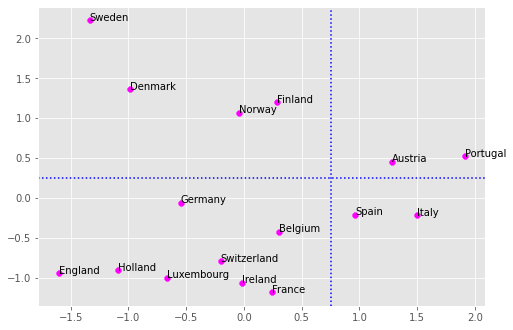

In [9]:
plt.style.use('ggplot') 
fig, ax = plt.subplots()
fig.set_size_inches([8,5.5])
ax.scatter(dim1, dim2,marker='8',c='#FF00FF')
for i, txt in enumerate(country):
    ax.annotate(txt, (dim1[i], dim2[i]))
ax.axvline(x = 0.75, color = 'b',linestyle=':')
ax.axhline(y = 0.25, color = 'b',linestyle=':')

Each food's consumption for all countries as the “feature” vectors, each food is a data point.

In [10]:
food_type=list(food.columns[1:])

In [11]:
#food_data: each row is a country(feature), each col is a food(data point),m=国家数，n=food数
std_country=np.std(food_data,axis=1)
food_data_stand1 = food_data.T @ np.diag(np.ones(std_country.shape[0])/std_country)
food_data_stand1 = food_data_stand1.T #change to each row is a country(feature)
mu1=np.mean(food_data_stand1,axis=1)
food_data_stand1 = food_data_stand1 - mu1.reshape(m,1) # center data cloud

In [12]:
C1 = (food_data_stand1@food_data_stand1.T)/n

In [13]:
eigenvalues1, eigenvectors1 =np.linalg.eigh(C1)

In [14]:
dim11 = eigenvectors1[:,-1].T@food_data_stand1/np.sqrt(eigenvalues1[-1])
dim22 = eigenvectors1[:,-2].T@food_data_stand1/np.sqrt(eigenvalues1[-2])

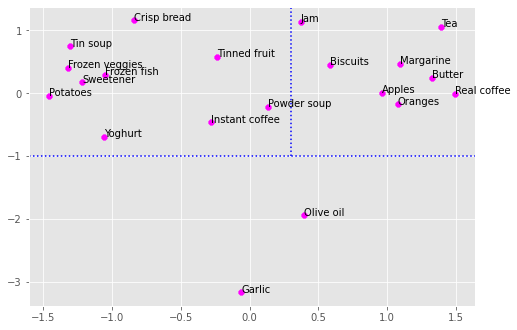

In [15]:
plt.style.use('ggplot') 
fig, ax = plt.subplots()
fig.set_size_inches([8,5.5])
ax.scatter(dim11, dim22,marker='8',c='#FF00FF')
for i, txt in enumerate(food_type):
    ax.annotate(txt, (dim11[i], dim22[i]))
ax.axvline(x = 0.3, color = 'b',linestyle=':',ymin=0.5, ymax=1)
ax.axhline(y = -1, color = 'b',linestyle=':')

It is interesting that the fruits like apples, oranges are close to each other. Butter, margarine, real coffee, biscuits and tea are close to each other. These are all the food for my breakfast. All countries consume apples and oranges are similar. But for garlic(same as olive oil), some counties really like it, some counties don't like it at all.

## Order of faces using ISOMAP

In [16]:
isomap = sio.loadmat('isomap.mat')

In [17]:
isomap=isomap['images']
isomap.shape #each col=1 picture

(4096, 698)

#### Start form the A matrix, and tune $\epsilon$, make sure each node has at least one neighbor

In [18]:
isomap[:,0].reshape(4096,1)

array([[0.01617647],
       [0.01617647],
       [0.01617647],
       ...,
       [0.        ],
       [0.        ],
       [0.        ]])

In [19]:
shortest_distance=[]
for i in range(698):
    all_distance_to_i=np.linalg.norm(isomap-isomap[:,i].reshape(4096,1),2,axis=0) #应该有698个距离，取min
    shortest_distance.append(sorted(all_distance_to_i)[1])# 选第一个不是0的最短距离，0是和自己的距离
print(shortest_distance[:20])

[5.58853527039493, 3.611865999288786, 2.2263127586412663, 5.726981083786483, 5.351127656724065, 5.620447630502684, 5.492231301153187, 4.937500586330031, 4.302284381202669, 4.266432103470917, 6.868822506120072, 2.749063980082888, 7.493084180670531, 6.939592782354444, 5.316343567464801, 4.081068957733284, 6.31380924074996, 6.89765813028481, 5.252132238682516, 5.740872406395071]


In [20]:
try1=np.linalg.norm(isomap-isomap[:,0].reshape(4096,1),2,axis=0)#check each picture's min distance to all other pic

In [21]:
epsilon=max(shortest_distance) # so all nodes have at least 1 neighbor
print(epsilon) # this is the lower bound of epsilon!

9.727052708864418


In [22]:
#Let's use epsilon=9.73 as the 1st epsilon, form a sparse matrix A
row=[]
col=[]
value=[]
for i in range(698):
    all_distance_to_i=np.linalg.norm(isomap-isomap[:,i].reshape(4096,1),2,axis=0)
    
    mask=all_distance_to_i<=9.73
    col_index=np.flatnonzero(mask)
    col+=list(col_index)
    row+=[i]*len(col_index)
    value+=list(all_distance_to_i[mask])


In [23]:
print(len(row),len(col),len(value))

12150 12150 12150


We can tell there are total 12150 values in matrix A with epsilon=9.73, this including 0 values on the main diagnol of A. The total size of A should be 698\*698=487204. Only 2.49\% of this matrix is with real numbers.

In [24]:
sparse_A=sp.coo_matrix((value, (row, col)),shape=(698,698)) 

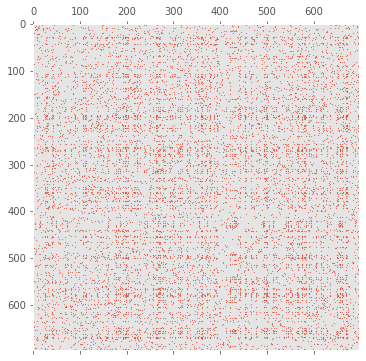

In [25]:
plt.style.use('ggplot') 
plt.figure(figsize=(6,6))
plt.spy(sparse_A, markersize=0.2)
plt.grid(False)

In [26]:
A_973=sparse_A.toarray()
sum(np.diag(A_973)!=0) # double check whether all values on the diagnol of A=0, and Yes, it is.

0

In [27]:
#看看有没有全0的行,没有！none of the row is all 0
mask_emptyrow=np.where(~A_973.any(axis=1))
mask_emptyrow                    

(array([], dtype=int64),)

In [28]:
#Let's use epsilon=12.5 as the 2nd epsilon, form a sparse matrix A
row_125=[]
col_125=[]
value_125=[]
for i in range(698):
    all_distance_to_i=np.linalg.norm(isomap-isomap[:,i].reshape(4096,1),2,axis=0)
    
    mask=all_distance_to_i<=12.5
    col_index=np.flatnonzero(mask)
    col_125+=list(col_index)
    row_125+=[i]*len(col_index)
    value_125+=list(all_distance_to_i[mask])

In [29]:
sparse_A_125=sp.coo_matrix((value_125, (row_125, col_125)),shape=(698,698)) 


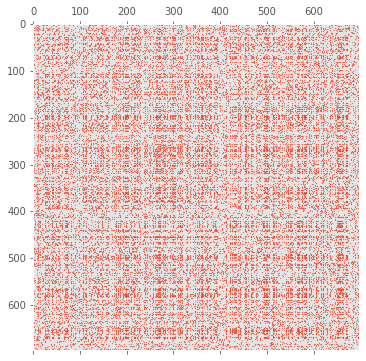

In [30]:
plt.figure(figsize=(6,6))
plt.spy(sparse_A_125, markersize=0.2)
plt.grid(False)

In [31]:
A_125=sparse_A_125.toarray()
sum(np.diag(A_125)!=0)

0

In [32]:
len(row_125)

34368

We can tell there are total 34368 values in matrix A with epsilon=12.5, this including 0 values on the main diagnol of A. The total size of A should be 698\*698=487204. This time, 34368/487204=7.05\% of this matrix is with real numbers.

In [33]:
#Let's use epsilon=15.5 as the 3rd epsilon, form a sparse matrix A
row_155=[]
col_155=[]
value_155=[]
for i in range(698):
    all_distance_to_i=np.linalg.norm(isomap-isomap[:,i].reshape(4096,1),2,axis=0)
    
    mask=all_distance_to_i<=15.5
    col_index=np.flatnonzero(mask)
    col_155+=list(col_index)
    row_155+=[i]*len(col_index)
    value_155+=list(all_distance_to_i[mask])

In [34]:
sparse_A_155=sp.coo_matrix((value_155, (row_155, col_155)),shape=(698,698))

In [35]:
#mask_155=np.array(row_155)==np.array(col_155)

#index_155=np.flatnonzero(mask_155)
#row_155_try = [e for i, e in enumerate(row_155) if i not in index_155]
#col_155_try=[e for i, e in enumerate(col_155) if i not in index_155]
#value_155_try=[e for i, e in enumerate(value_155) if i not in index_155]
#sparse_A_155_try=sp.coo_matrix((value_155_try, (row_155_try, col_155_try)),shape=(698,698)) 

In [36]:
#plt.figure(figsize=(8,8))
#plt.spy(sparse_A_155_try,markersize=0.2)

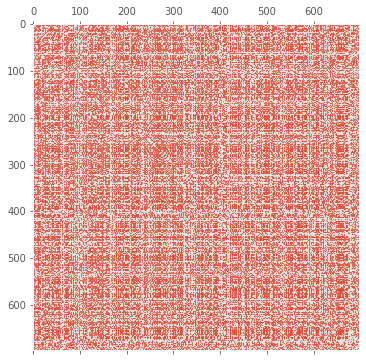

In [37]:
plt.figure(figsize=(6,6))
plt.spy(sparse_A_155,markersize=0.2)
plt.grid(False)

In [38]:
len(row_155)

84204

We can tell there are total 84204 values in matrix A with epsilon=15.5, the density=84204/487204=17.28\%

#### Plot 3 groups of images with distance<=3.0, in A matrix with epsilon=12.50

In [39]:
mask_similar1=np.array(value_125)<=3
mask_similar2=np.array(value_125)!=0
mask_similar=mask_similar1&mask_similar2
index_close=np.flatnonzero(mask_similar)
index_close

array([  116,   543,   937,  1043,  1110,  1171,  1175,  1439,  1497,
        1542,  1701,  1730,  1735,  1892,  1899,  2269,  2785,  2843,
        2998,  3002,  3394,  3659,  4127,  4146,  4258,  4328,  4432,
        4450,  4604,  4680,  5039,  5175,  5246,  5442,  5784,  6229,
        6262,  6520,  6785,  6896,  7001,  7283,  7294,  7369,  7488,
        7593,  7762,  8053,  8816,  8858,  8860,  9099,  9238,  9259,
        9263,  9422,  9512,  9690,  9755,  9922,  9973, 10555, 10646,
       10886, 11115, 11124, 11827, 12413, 13252, 13701, 13793, 14349,
       14353, 14947, 15063, 15230, 15281, 15314, 15666, 15715, 15753,
       15916, 16101, 16220, 16287, 16567, 16845, 17073, 17358, 17447,
       17531, 17616, 17625, 17858, 17920, 17948, 17995, 18237, 18347,
       18561, 18977, 19066, 19099, 19600, 19691, 20283, 20357, 20553,
       20560, 20733, 20872, 20921, 21368, 21373, 21422, 21897, 22484,
       22496, 22654, 22813, 23020, 23045, 23066, 23104, 24010, 24185,
       24303, 24307,

These are the index in value array for coo matrix sparse_A, each index correponding a pair picturs whose distance is super close to each other

In [40]:
print(row_125[7001],col_125[7001]) #the 1st pair for index=116

150 495


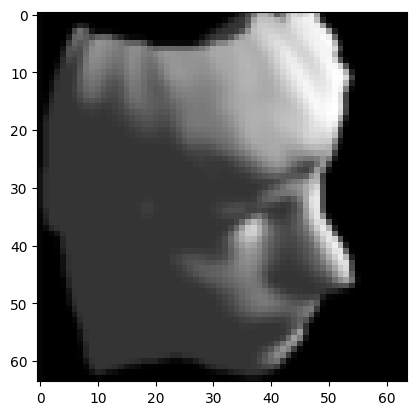

In [41]:
plt.style.use('default')
pic_150=np.reshape(isomap[:,150], (64, 64), order="F")
plt.imshow(pic_150, cmap='gray')
plt.grid(False)

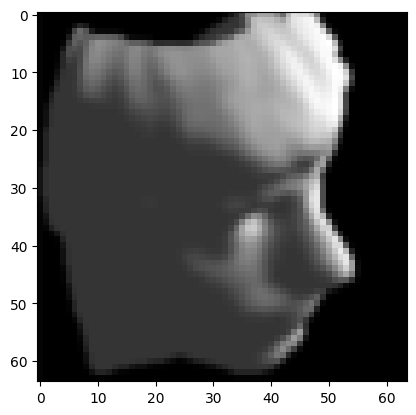

In [42]:
pic_495=np.reshape(isomap[:,495], (64, 64), order="F")
plt.imshow(pic_495, cmap='gray')
plt.grid(False)

In [43]:
print(row_125[20921],col_125[20921]) #the 2nd pair for index=20921

432 661


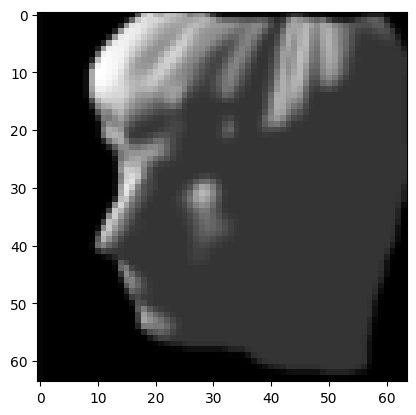

In [44]:
pic_432=np.reshape(isomap[:,432], (64, 64), order="F")
plt.imshow(pic_432, cmap='gray')
plt.grid(False)

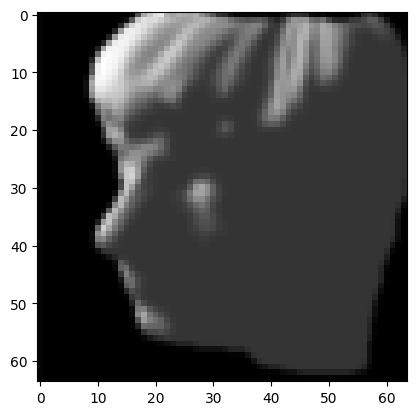

In [45]:
pic_661=np.reshape(isomap[:,661], (64, 64), order="F")
plt.imshow(pic_661, cmap='gray')
plt.grid(False)

In [46]:
print(row_125[3659],col_125[3659]) #the 2nd pair for index=3659

75 36


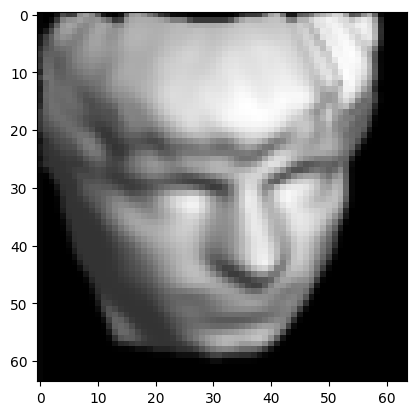

In [47]:
pic_75=np.reshape(isomap[:,75], (64, 64), order="F")
plt.imshow(pic_75, cmap='gray')
plt.grid(False)

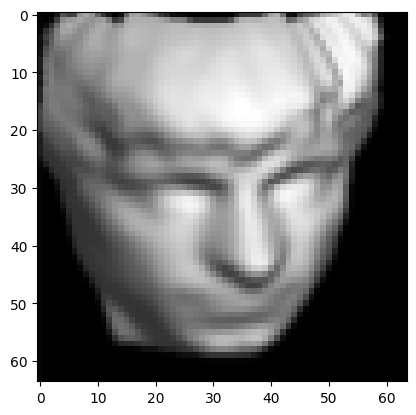

In [48]:
pic_36=np.reshape(isomap[:,36], (64, 64), order="F")
plt.imshow(pic_36, cmap='gray')
plt.grid(False)

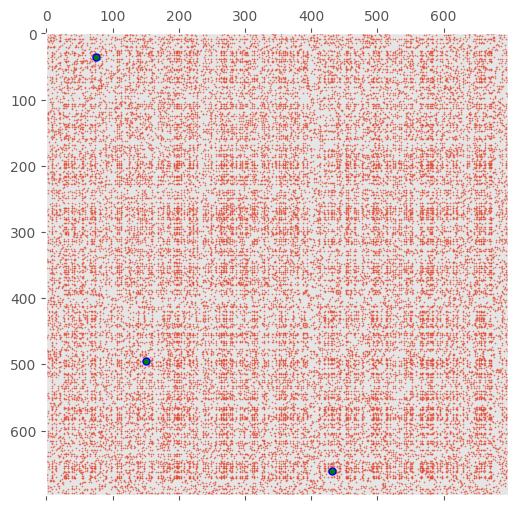

In [49]:
plt.style.use('ggplot') # will use praphic dessign tool to put the head pictures on this plot
plt.figure(figsize=(6,6))
plt.spy(sparse_A_125, markersize=0.2)
plt.plot(75, 36, marker="o", markersize=5, markeredgecolor="blue", markerfacecolor="green")
plt.plot(432, 661, marker="o", markersize=5, markeredgecolor="blue", markerfacecolor="green")
plt.plot(150, 495, marker="o", markersize=5, markeredgecolor="blue", markerfacecolor="green")
plt.grid(False)

## Implement the ISOMAP algorithm to obtain a two-dimensional (low-dimensional) embedding

#### Start form the D matrix

Let's use the sparse matrix A with epsilon=12.5 to form matrix D. I have tried epsilon=9.73, still have inf value in D

In [50]:
D=sp.csgraph.shortest_path(A_125,method='FW',directed=False)

In [51]:
H=np.diag(np.ones(698))-np.ones(698).reshape(698,1)@np.ones(698).reshape(1,698)/698

In [52]:
C=-0.5*H@(D*D)@H
C.shape

(698, 698)

In [53]:
np.max(D)

97.81014242992522

In [54]:
eigenvalues_C, eigenvectors_C =np.linalg.eigh(C)

In [55]:
eigen_col1=eigenvectors_C[:,-1].reshape(698,1)
eigen_col2=eigenvectors_C[:,-2].reshape(698,1)
Z_w=np.append(eigen_col1,eigen_col2,axis=1)
Z_transpose=Z_w@np.diag(np.sqrt(eigenvalues_C[-2:][::-1]))

In [56]:
Z_transpose

array([[ 19.66147668,  -1.33483423],
       [-19.80026988,   1.27894319],
       [ 19.19282034,  -6.01263835],
       ...,
       [-10.02287999,  18.56270614],
       [-25.29062006,  -6.72885601],
       [ 10.12165075,   8.27682108]])

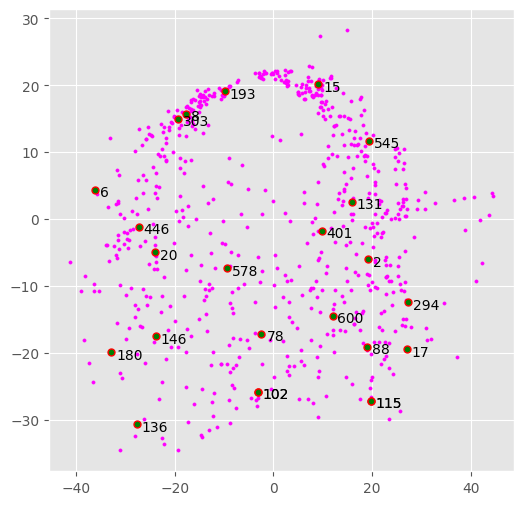

In [57]:
plt.style.use('ggplot')
fig, ax = plt.subplots()
fig.set_size_inches([6,6])
ax.scatter(Z_transpose[:,0], Z_transpose[:,1],c='#FF00FF',s=5)

for i in [2,8,6,15,17,20,78,115,131,193,294,545,578,303,401,446,600,102,88, 102, 115, 136, 146,180]:
    plt.plot(Z_transpose[i,:][0], Z_transpose[i,:][1], marker="o", markersize=5, markeredgecolor="red", markerfacecolor="green")
    plt.text(Z_transpose[i,:][0]+1, Z_transpose[i,:][1]-1,i)


In [58]:
np.flatnonzero(Z_transpose[:,1]<-17) #node 9, 15, 26


array([ 17,  18,  23,  31,  36,  44,  48,  54,  61,  65,  70,  75,  77,
        78,  79,  82,  83,  87,  88, 102, 104, 115, 116, 136, 146, 147,
       162, 174, 175, 179, 180, 191, 195, 206, 207, 218, 223, 238, 242,
       251, 257, 260, 274, 285, 305, 309, 320, 321, 324, 331, 336, 338,
       340, 343, 350, 356, 373, 383, 384, 393, 395, 397, 404, 410, 414,
       415, 423, 427, 436, 445, 447, 450, 451, 463, 464, 471, 473, 474,
       489, 506, 509, 516, 518, 521, 525, 527, 528, 530, 531, 532, 534,
       539, 542, 558, 561, 563, 577, 585, 593, 602, 606, 611, 613, 621,
       624, 627, 633, 637, 641, 644, 652, 665, 673, 683, 689, 693])

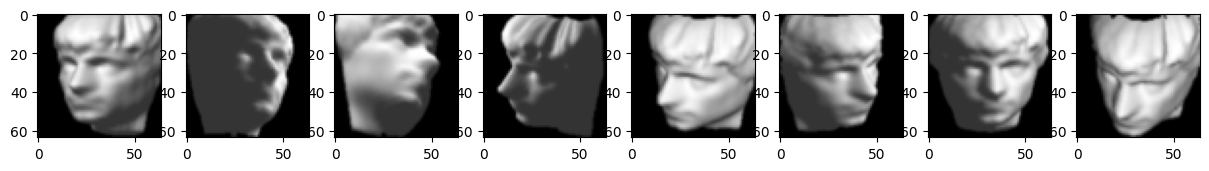

In [59]:
#plot all pictures to hand put on scatter plot later
plt.style.use('default')
fig, axe = plt.subplots(1,8)
fig.set_size_inches([15,10])
pic=0
for i in [2,8,6,15,17,20,78,115]:   
    axe[pic].imshow(np.reshape(isomap[:,i], (64, 64), order="F"),cmap='gray')
    pic+=1

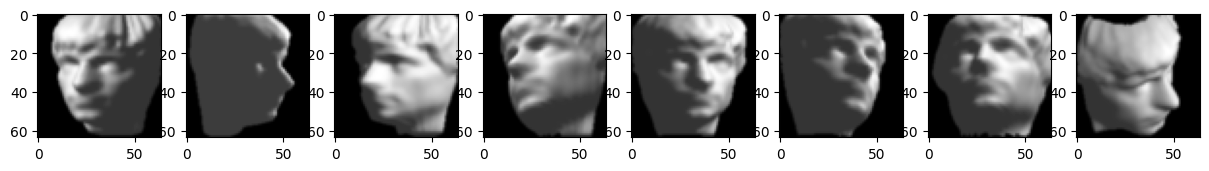

In [60]:
fig, axe = plt.subplots(1,8)
fig.set_size_inches([15,10])
pic=0
for i in [131,193,294,545,578,303,401,446]:    
    axe[pic].imshow(np.reshape(isomap[:,i], (64, 64), order="F"),cmap='gray')
    pic+=1

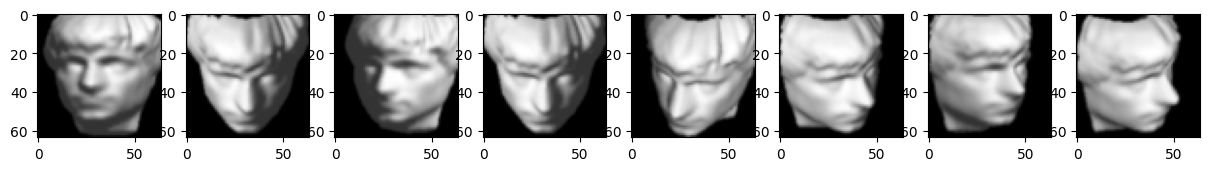

In [61]:
fig, axe = plt.subplots(1,8)
fig.set_size_inches([15,10])
pic=0
for i in [600,102,88,102,115,136,146,180]:
    axe[pic].imshow(np.reshape(isomap[:,i], (64, 64), order="F"),cmap='gray')
    pic+=1

Using PCA for this dataset. This is image data, based on prof X, the std won't changed a lot for each features. So we can either standard the data or not. I just perform the standardize here for aligning with other PCA questions.

In [62]:
std_isomap=np.std(isomap,axis=1)+0.0000000001 # avoid divided by 0 trick
isomap_stand = isomap.T @ np.diag(np.ones(std_isomap.shape[0])/std_isomap) #698*4096
isomap_stand = isomap_stand.T #change to each col is a picture, each row is a pixel feature
isomap_mu=np.mean(isomap_stand,axis=1)
isomap_stand = isomap_stand - isomap_mu.reshape(4096,1) # center data cloud

In [63]:
C_isomap = (isomap_stand@isomap_stand.T)/698

In [64]:
eigenvalues_iso, eigenvectors_iso =np.linalg.eigh(C_isomap)

In [65]:
dim1_iso = eigenvectors_iso[:,-1].T@isomap_stand/np.sqrt(eigenvalues_iso[-1])
dim2_iso = eigenvectors_iso[:,-2].T@isomap_stand/np.sqrt(eigenvalues_iso[-2])

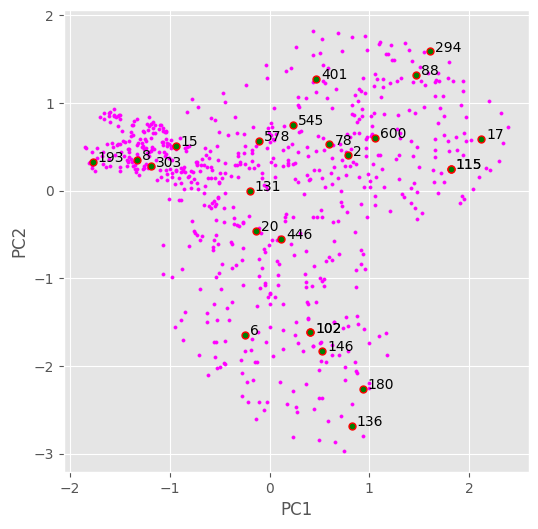

In [66]:
plt.style.use('ggplot') 
fig, ax = plt.subplots()
fig.set_size_inches([6,6])
ax.scatter(dim1_iso, dim2_iso,c='#FF00FF',s=5)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
for i in [2,8,6,15,17,20,78,115,131,193,294,545,578,303,401,446,600,102,88, 102, 115, 136, 146,180]:
    plt.plot(dim1_iso[i], dim2_iso[i], marker="o", markersize=5, markeredgecolor="red", markerfacecolor="green")
    plt.text(dim1_iso[i]+0.05, dim2_iso[i],i)

## Eigenfaces and simple face recognition

In [67]:
def read_img(path):
    """
    Read image and store it as an array, given the image path. 
    Returns the 3 dimensional image array.
    """
    img = Image.open(path)
    img_arr = np.array(img)
    img.close()
    return img_arr

In [68]:
s2=read_img('yalefaces/subject02.glasses.gif')
m,n=s2[::4,::4].shape
print(s2.shape)
print(s2[::4,::4].shape) #downsize the pic by 4 steps between each col and row 

(243, 320)
(61, 80)


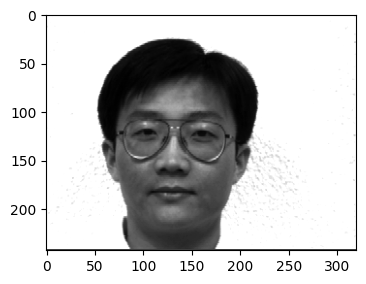

In [69]:
#original pic
plt.style.use('default') 
plt.figure(figsize = (4,4))
plt.imshow(s2, cmap='gray')

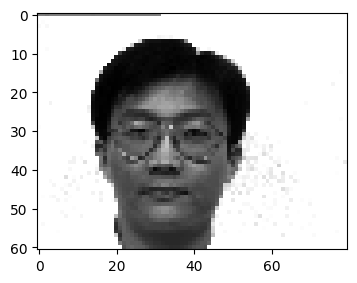

In [70]:
#downsize pic
plt.figure(figsize = (4,4))
plt.imshow(s2[::4,::4], cmap='gray') 

Try on the pictures of subject01:

In [71]:
pic01_list=['glasses','happy','leftlight','noglasses','normal','rightlight','sad','sleepy','surprised','wink']

In [72]:
lst=[]
for i in pic01_list:
    pic=read_img(f'yalefaces/subject01.{i}.gif')  
    pic=pic[::4,::4]
    pic=pic.reshape(m*n,1,order='F') # stack each col on top of each other. It is a col vector
    lst.append(pic)
pic01=np.hstack(lst)
print(pic01.shape)

(4880, 10)


The matrix pic01's each col is a pic and row are features.

In [73]:
#尝试没有standardize原始的图，只是中心化，再中心化test pic之后得多少
pic01_mu=np.mean(pic01,axis=1)
pic01 = pic01 - pic01_mu.reshape(m*n,1) # center data cloud

In [74]:
U1, _, _ = np.linalg.svd(pic01, full_matrices=False) #Use SVD

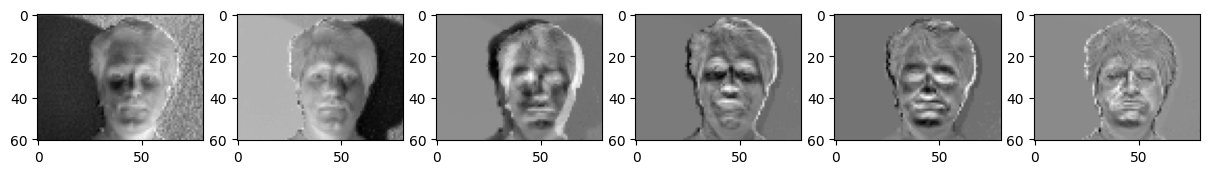

In [75]:
plt.style.use('default')
fig, axe = plt.subplots(1,6)
fig.set_size_inches([15,10])
index=0
for i in range(6):
    pic=U1[:,i].reshape(m,n,order='F')
    axe[index].imshow(pic,cmap='gray')
    index+=1 

In [76]:
U1[:,0]#take a look

array([-0.01053209, -0.01981846, -0.02129069, ..., -0.00822743,
       -0.01099957, -0.00867028])

Try on the pictures of subject02:

In [77]:
pic02_list=['glasses','happy','leftlight','noglasses','normal','rightlight','sad','sleepy','wink']

In [78]:
lst2=[]
for i in pic02_list:
    pic=read_img(f'yalefaces/subject02.{i}.gif')  
    pic=pic[::4,::4]
    pic=pic.reshape(m*n,1,order='F') # stack each col on top of each other. It is a col vector
    lst2.append(pic)
pic02=np.hstack(lst2)
print(pic02.shape)

(4880, 9)


In [79]:
pic02_mu=np.mean(pic02,axis=1)
pic02 = pic02 - pic02_mu.reshape(m*n,1) # center data cloud

In [80]:
U2, _, _ = np.linalg.svd(pic02, full_matrices=False) #Use SVD

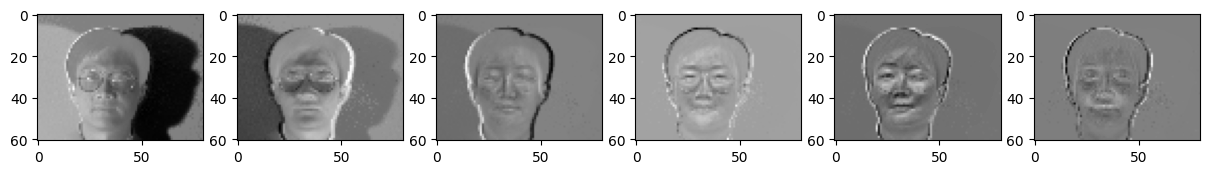

In [81]:
fig, axe = plt.subplots(1,6)
fig.set_size_inches([15,10])
index=0
for i in range(6):
    pic=U2[:,i].reshape(61,80,order='F')
    axe[index].imshow(pic,cmap='gray')
    index+=1 

### Not center the test image and calculate the projection residual

Please ignor these numebrs since it is not centered. Only check the centered ones below.

In [82]:
#calculate s_11
test1=read_img(f'yalefaces/subject01-test.gif')
test1=test1[::4,::4].reshape(m*n,1,order='F')

test2=read_img(f'yalefaces/subject02-test.gif')
test2=test2[::4,::4].reshape(m*n,1,order='F')

In [83]:
pc1=U1[:,0].reshape(4880,1) # larget eigenface of subject 1
pc2=U2[:,0].reshape(4880,1) # larget eigenface of subject 2
#calculate s_11
s_11=np.linalg.norm(test1-pc1@(pc1.T@test1),2)**2
s_11

49933494.118110016

In [84]:
s_12=np.linalg.norm(test2-pc1@(pc1.T@test2),2)**2
s_12

113948550.40833539

In [85]:
#calculate s_21, 还是白人图片对 pc2
s_21=np.linalg.norm(test1-pc2@(pc2.T@test1),2)**2
s_21 

199761842.69999745

In [86]:
s_22=np.linalg.norm(test2-pc2@(pc2.T@test2),2)**2
s_22 

181971406.0230801

### Center the test image and calculate the projection residual

If I center my test1 and test2 images according to the certain eigenfaces when calculationg the projection residual, the residual decreased a lot! I think this makes the projection more sense, since what preprocess be done on the original images for training, the same preprocess should be done on the test data. This makes the comparation fair. 

I think we can put it in this way: "moving the test datapoint to the proper coordinate system".

In [87]:
test1_center_pc1=test1-pic01_mu.reshape(m*n,1)

s11_center=np.linalg.norm(test1_center_pc1-pc1@(pc1.T@test1_center_pc1),2)**2
s11_center

7201612.087076738

In [88]:
test2_center_pc1=test2-pic01_mu.reshape(m*n,1)
s12_center=np.linalg.norm(test2_center_pc1-pc1@(pc1.T@test2_center_pc1),2)**2
s12_center

40637771.64677801

In [89]:
test1_center_pc2=test1-pic02_mu.reshape(m*n,1)
s21_center=np.linalg.norm(test1_center_pc2-pc2@(pc2.T@test1_center_pc2),2)**2
s21_center

33747074.49968636

In [90]:
test2_center_pc2=test2-pic02_mu.reshape(m*n,1)
s22_center=np.linalg.norm(test2_center_pc2-pc2@(pc2.T@test2_center_pc2),2)**2
s22_center

4242539.908491638

### Plot scatter plot of  all 19 images using pc1 from subject 1 and pc1 from subject 2

In [91]:
subject1_pc11=U1[:,0].T@pic01 # x coordinate(pc1 from subject 1) for subject 1 
subject1_pc12=U2[:,0].T@(np.hstack(lst)-pic02_mu.reshape(m*n,1))# y coordinate(pc1 from subject 2) for subject 1 
subject2_pc11=U1[:,0].T@(np.hstack(lst2)-pic01_mu.reshape(m*n,1))# x coordinate(pc1 from subject 1) for subject 2
subject2_pc12=U2[:,0].T@pic02 # y coordinate(pc1 from subject 2) for subject 2

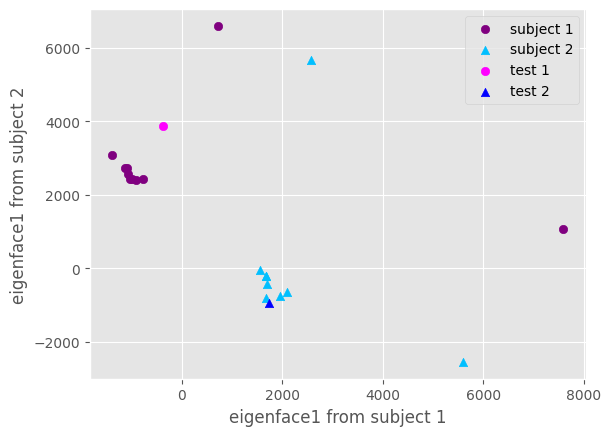

In [92]:
plt.style.use('ggplot') 
fig, ax = plt.subplots()
#fig.set_size_inches([6,4])
ax.scatter(subject1_pc11,subject1_pc12,color='purple',label='subject 1')
ax.scatter(subject2_pc11,subject2_pc12,color='deepskyblue',marker='^',label='subject 2')
ax.scatter(pc1.T@test1_center_pc1,pc2.T@test1_center_pc2,color='fuchsia',label='test 1')
ax.scatter(pc1.T@test2_center_pc1,pc2.T@test2_center_pc2,color='b',marker='^',label='test 2')
ax.set_xlabel('eigenface1 from subject 1')
ax.set_ylabel('eigenface1 from subject 2')
ax.legend(loc='upper right')

In [93]:
print(pc1.T@test1_center_pc1/np.linalg.norm(test1,2))
print(pc1.T@test2_center_pc1/np.linalg.norm(test2,2)) # 没有center 化test1, test2 for 后面的这个norm

[[-0.02556635]]
[[0.11835048]]


### Try to combine the subject 1 and 2 to do PCA, project our new test image 1 and 2 on pc1 and pc2

In [94]:
lst_combine=lst+lst2
pic_combine=np.hstack(lst_combine)
combine_mu=np.mean(pic_combine,axis=1)
pic_combine_center=pic_combine-combine_mu.reshape(m*n,1)

In [95]:
U_combine, _, _ = np.linalg.svd(pic_combine_center, full_matrices=False) #Use SVD

In [96]:
# project all subject 1 on pc1 and pc2
# row 0 is coordinate for all subject 1 image on pc1
dim1_combine=U_combine[:,:2].T@(np.hstack(lst) - combine_mu.reshape(m*n,1)) 

#subject 2
dim2_combine=U_combine[:,:2].T@(np.hstack(lst2) - combine_mu.reshape(m*n,1)) 

#test 1 image
test1_combine=U_combine[:,:2].T@(test1-combine_mu.reshape(m*n,1))
#test 2 image
test2_combine=U_combine[:,:2].T@(test2-combine_mu.reshape(m*n,1))

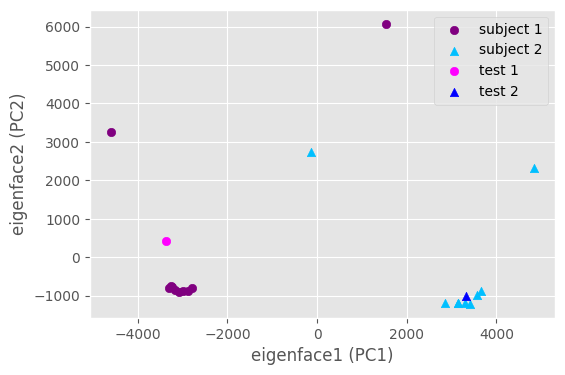

In [97]:
#plot on 2 dimentional face space 1 and 2
plt.style.use('ggplot') 
fig, ax = plt.subplots()
fig.set_size_inches([6,4])
ax.scatter(dim1_combine[0,:],dim1_combine[1,:],color='purple',label='subject 1')
ax.scatter(dim2_combine[0,:],dim2_combine[1,:],marker='^',color='deepskyblue',label='subject 2')
ax.scatter(test1_combine[0,:],test1_combine[1,:],color='fuchsia',label='test 1')
ax.scatter(test2_combine[0,:],test2_combine[1,:],marker='^',color='b',label='test 2')
ax.set_xlabel('eigenface1 (PC1)')
ax.set_ylabel('eigenface2 (PC2)')
ax.legend(loc='upper right')

In [98]:
# project all subject 1 on pc4 and pc5

dim1_combine_pc45=U_combine[:,3:5].T@(np.hstack(lst) - combine_mu.reshape(m*n,1)) 

# project all subject 2 on pc4 and pc5
dim2_combine_pc45=U_combine[:,3:5].T@(np.hstack(lst2) - combine_mu.reshape(m*n,1)) 

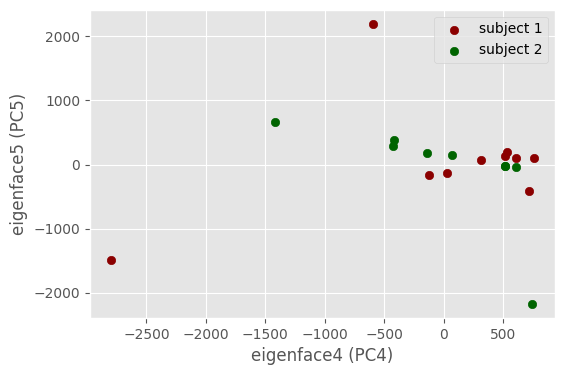

In [99]:
# plot on 2 dimentional face space 4 and 5
# I didn't see any clustering pattern here. So ignoring it.
fig, ax = plt.subplots()
fig.set_size_inches([6,4])

ax.scatter(dim1_combine_pc45[0,:],dim1_combine_pc45[1,:],color='darkred',label='subject 1')
ax.scatter(dim2_combine_pc45[0,:],dim2_combine_pc45[1,:],color='darkgreen',label='subject 2')
ax.set_xlabel('eigenface4 (PC4)')
ax.set_ylabel('eigenface5 (PC5)')
ax.legend(loc='upper right')

Additional experiment, please ignor below.

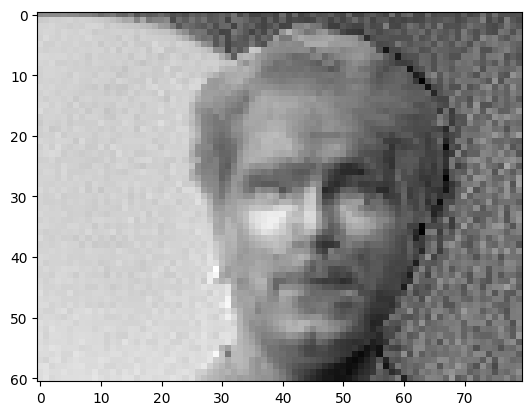

In [100]:
# PROJECT the test image 1 on pc1
plt.style.use('default')
project_1_to_pc1=pc1@(pc1.T@test1_center_pc1)
plt.imshow(project_1_to_pc1.reshape(61,80,order='F'), cmap='gray') 

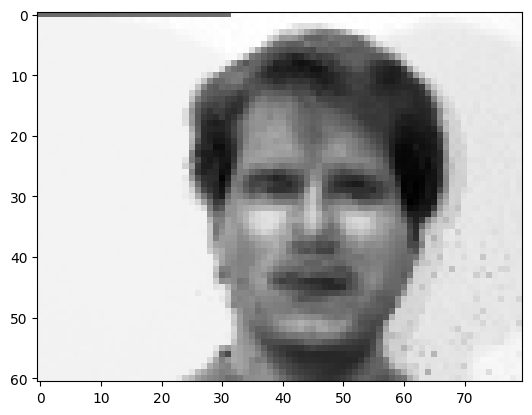

In [101]:
#add subject 1 center back and plot
plt.imshow((project_1_to_pc1+pic01_mu.reshape(m*n,1)).reshape(61,80,order='F'), cmap='gray')

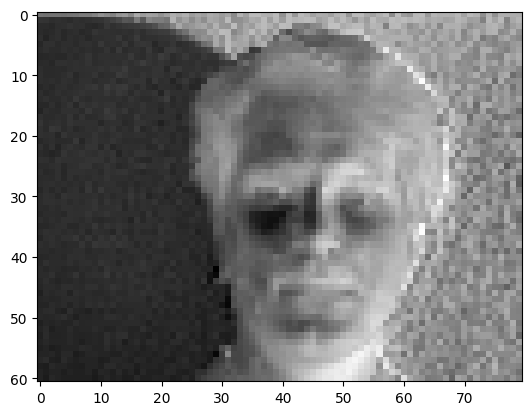

In [102]:
# PROJECT the test image 2 on pc1

project_2_to_pc1=pc1@pc1.T@test2_center_pc1
plt.imshow(project_2_to_pc1.reshape(61,80,order='F'), cmap='gray') 

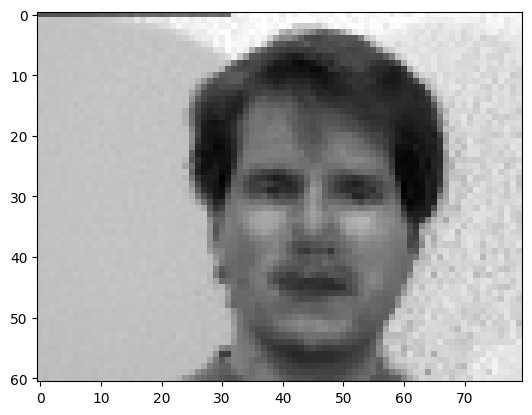

In [103]:
#add subject 1 center back and plot
plt.imshow((project_2_to_pc1+pic01_mu.reshape(m*n,1)).reshape(61,80,order='F'), cmap='gray')

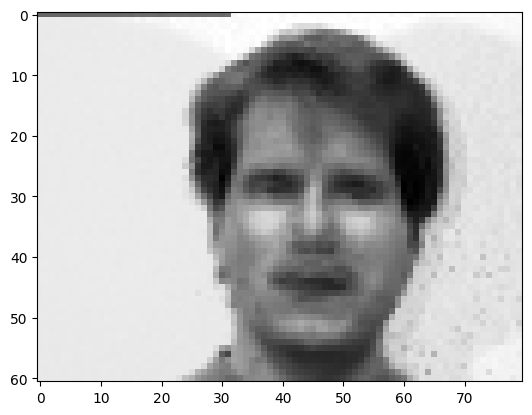

In [104]:
#  mean face of subject 1
plt.imshow(pic01_mu.reshape(m,n,order='F'),cmap='gray')